## Lab4-Regression-using-PyTorch

### SAKSHAM BHUJEL
### ACE080BCT063



### THEORY:

1. PyTorch

PyTorch is an open-source machine learning framework developed by Meta. It provides tools for tensor computation, automatic differentiation, and building deep learning models.

2. Regression

Regression is a supervised machine learning technique used to model the relationship between input variables and output variables. The objective is to predict continuous numerical values.

3. Quadratic Regression

Quadratic regression is a non-linear regression technique that models data using a second-degree polynomial equation:

y=ax2+bx+c

where:

a controls the curvature of the parabola.

b controls the slope.

c is the intercept.

Quadratic regression is useful when the relationship between variables follows a curved pattern rather than a straight line.

4. Neural Network Module (nn.Module)

In PyTorch, custom models are created by inheriting from nn.Module. This provides functionalities such as parameter management, training mode, and automatic differentiation.

5. Parameters

The model contains three trainable parameters:

a
b
c

These parameters are initialized randomly and updated during training using gradient descent.

6. Forward Propagation

The forward method defines how input data passes through the model to generate predictions:

return self.a * x**2 + self.b * x + self.c

7. Loss Function

The model uses Mean Absolute Error (MAE) loss:

MAE= 1/n * ∑ ∣y−y^​∣


MAE measures the average absolute difference between actual and predicted values.

8. Optimizer

The Stochastic Gradient Descent (SGD) optimizer updates model parameters by minimizing the loss function using gradients computed during backpropagation.

9. Training Process

The training process consists of:

Forward pass
Loss calculation
Gradient computation (loss.backward())
Parameter update (optimizer.step())
Repeating for multiple epochs


10. Evaluation

After training, the model is evaluated on testing data to determine how well it generalizes to unseen samples.

In [205]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [206]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## TASK 1: {DATASET = assignment-data.csv}

# 1. Data Preparation

In [207]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [208]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


### Train-Test Split

In [209]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Data Visualization Function

In [210]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

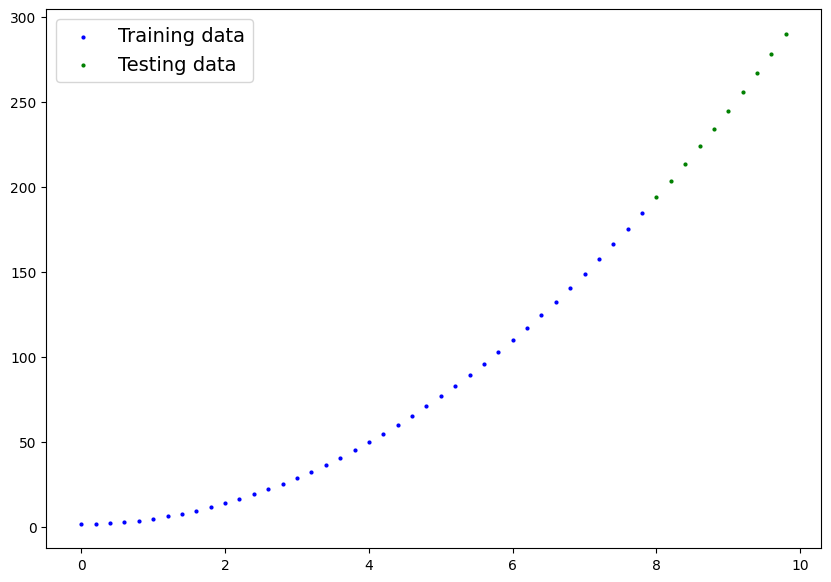

In [211]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## Algorithm Selection

We define a custom model:

y=ax2+bx+c

Explanation: These are learnable parameters which are initialized randomly.

They are updated during training using gradient descent.

In [212]:
# Create a Quadratic Regression model class
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.a = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.b = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.c = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [213]:
model_0 = QuadraticRegressionModel()

In [214]:
print(model_0.a.dtype)
print(model_0.b.dtype)
print(model_0.c.dtype)

torch.float32
torch.float32
torch.float32


In [215]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413]])

Explanation:

Here, predictions are made without gradient descent. It is used for evaluation only,

Output:

Initial predictions are untrained and do not align well with the actual data distribution.

In [216]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


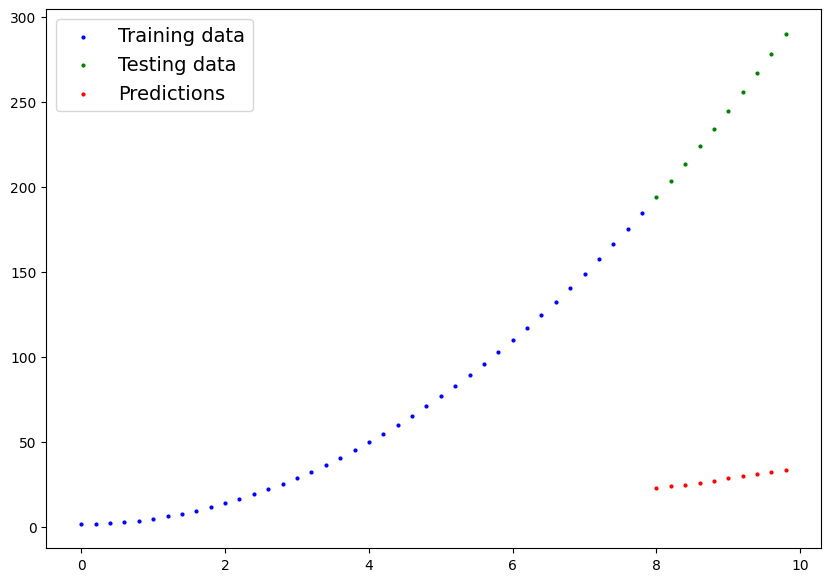

In [217]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [218]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error.

And,
SGD optimizer updates parameters to reduce error

In [219]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 500

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 55.967559814453125 | MAE Test Loss: 195.76417541503906 
Epoch: 10 | MAE Train Loss: 12.157402038574219 | MAE Test Loss: 28.818008422851562 
Epoch: 20 | MAE Train Loss: 2.427116870880127 | MAE Test Loss: 8.087414741516113 
Epoch: 30 | MAE Train Loss: 1.5925449132919312 | MAE Test Loss: 11.084966659545898 
Epoch: 40 | MAE Train Loss: 0.9689820408821106 | MAE Test Loss: 13.302360534667969 
Epoch: 50 | MAE Train Loss: 0.45725950598716736 | MAE Test Loss: 15.107688903808594 
Epoch: 60 | MAE Train Loss: 2.150113582611084 | MAE Test Loss: 8.50035285949707 
Epoch: 70 | MAE Train Loss: 1.5265477895736694 | MAE Test Loss: 10.717729568481445 
Epoch: 80 | MAE Train Loss: 1.0148272514343262 | MAE Test Loss: 12.52308177947998 
Epoch: 90 | MAE Train Loss: 0.6227549910545349 | MAE Test Loss: 13.890657424926758 
Epoch: 100 | MAE Train Loss: 1.0679795742034912 | MAE Test Loss: 12.078683853149414 
Epoch: 110 | MAE Train Loss: 0.7058199644088745 | MAE Test Loss: 13.3368434906005

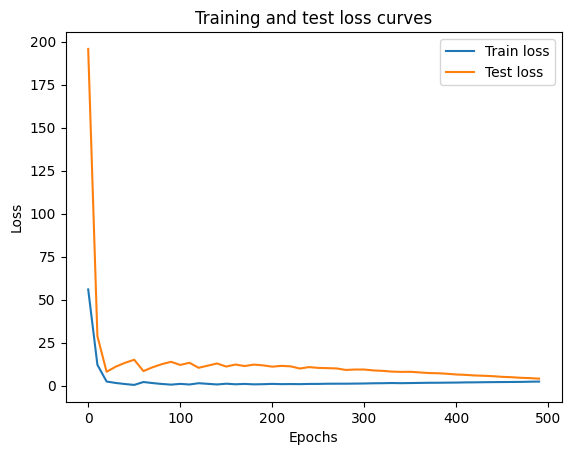

In [220]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

The curves shows training vs testing error which help to verify machine learning.

Output:

The decreasing curve shows that the model is learning.


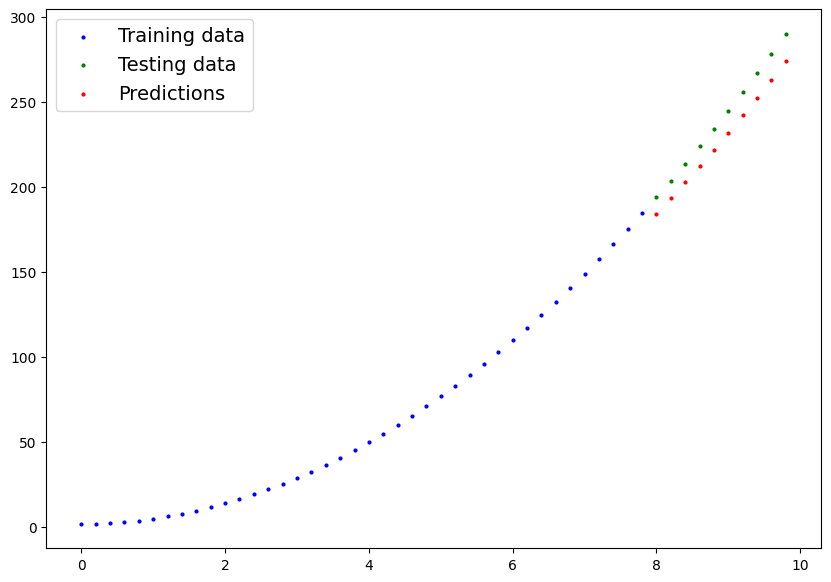

In [221]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

The Red points (predictions) align closely with actual data Indicates successful learning of quadratic relationship

## TASK 2: {DATASET = linear-regression-data1.csv.csv}

In [222]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [223]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


### 1. Data Preparation

In [224]:
import pandas as pd
import torch

df = pd.read_csv(r'linear-regression-data1.csv')
df.head(6)

,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356
5,0.10,0.370


In [225]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


Here, Shape of X and y confirms correct tensor conversion

### Train-Test Split

In [226]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Data Visualization Function

In [227]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

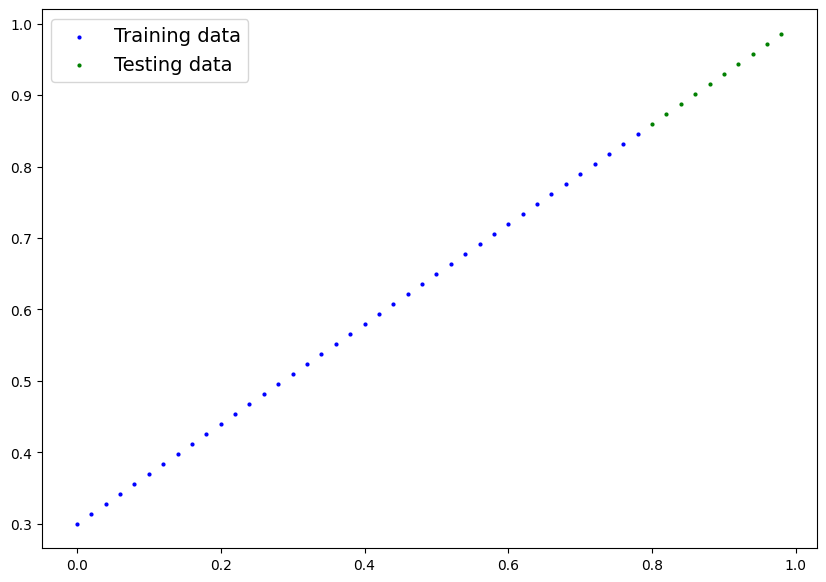

In [228]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function: Plots training data (blue), test data (green).

Output: Scatter plot showing dataset distribution Helps visually understand pattern (straight line)

### Algorithm Selection

We define a linear regression model: y = wx + b

This model is suitable because the dataset shows a straight-line relationship between input and output variables.

In [229]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.w = nn.Parameter(torch.randn(1, dtype=torch.float))
        self.b = nn.Parameter(torch.randn(1, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.w * x + self.b

model_0 = LinearRegressionModel()

In [230]:
print(model_0.w.dtype)
print(model_0.b.dtype)

torch.float32
torch.float32


In [231]:

# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251]])

In [232]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


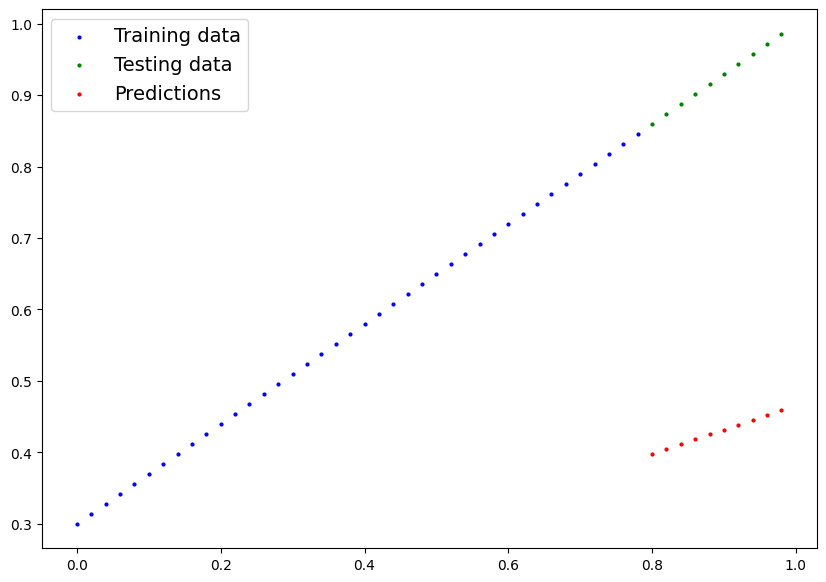

In [233]:
plot_predictions(predictions=y_preds)

Explanation:

Here, predictions are made without gradient descent. It is used for evaluation only,

Output:

Initial predictions are untrained and do not align well with the actual data distribution.

### Loss Function Selection

In [234]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error.

And,
SGD optimizer updates parameters to reduce error

In [235]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1600

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 


Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 
Epoch: 100 | MAE Train Loss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262 
Epoch: 110 | MAE Train Loss: 0.021020207554101944 | MAE Test Loss: 0.04819049686193466 
Epoch: 120 | MAE Train Loss: 0.01758546568453312 | MAE Test Loss: 0.04060482233762741 
Epoch: 130 | MAE Train Loss: 0.014155393466353416 | MAE Test Loss: 0.03233227878808975 
Epoch: 140 | MAE Train Loss: 0.0107165891677141

Output:

Model gradually learns the linear relationship between input and output variables by adjusting slope and intercept.

### Loss Curve Visualization

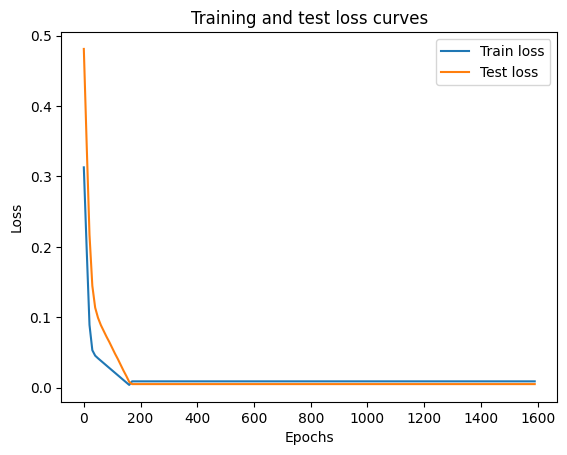

In [236]:

# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

The curves shows training vs testing error which help to verify machine learning.

Output:

The decreasing curve shows that the model is learning.


### Final Prediction Visualization

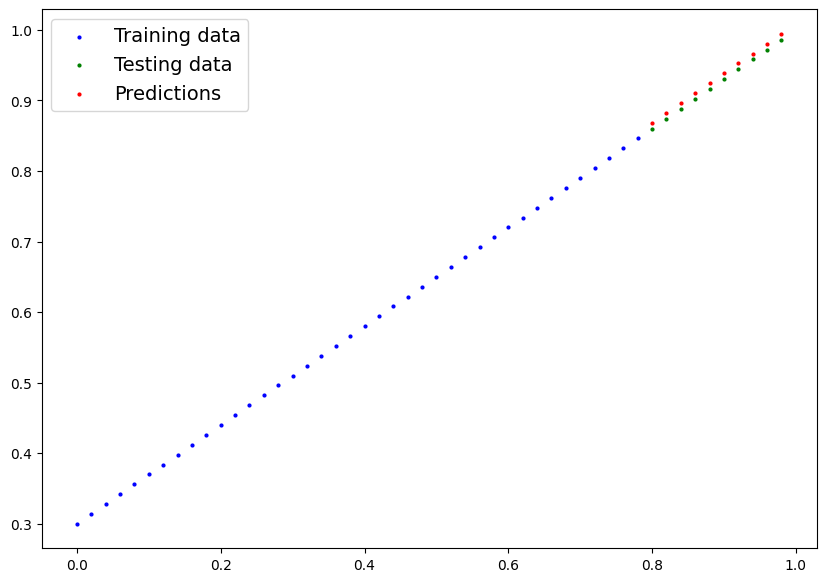

In [237]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

The Red points (predictions) align closely with actual data. Indicates successful learning of the linear relationship between variables.

## TASK 3: {DATASET = assignment-data2.csv}

### Data Preparation

In [238]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [239]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


Shape of X and y confirms correct tensor conversion

### Train-Test Split

In [240]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

Confirmed that the dataset is properly splitted into training and testing sets.

### Data Visualization Function

In [241]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

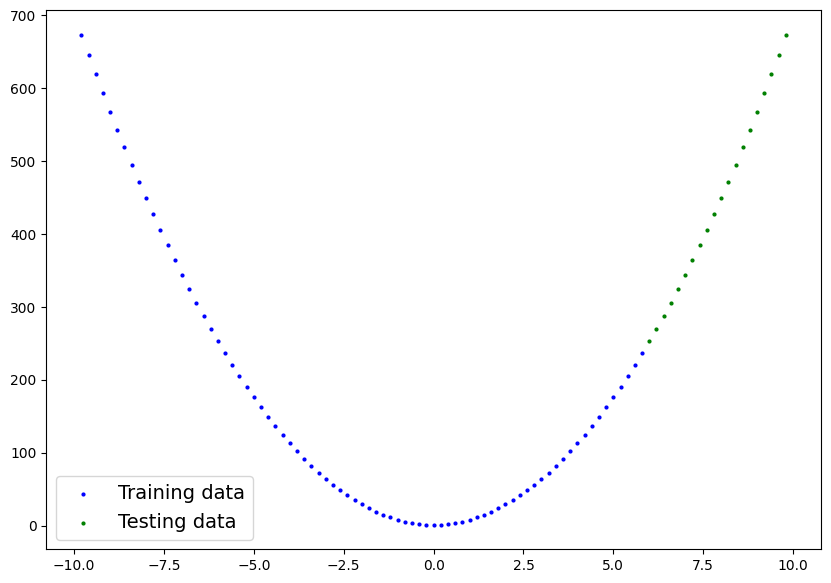

In [242]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function plots training data (blue), test data (green).

Output: Scatter plot showing dataset distribution helps visually understand pattern (quadratic curve)

### Algorithm Selection

We define a custom model:

y=ax2+bx+c

Explanation: These are learnable parameters

Initialized randomly

Updated during training using gradient descent

In [243]:
# Create a Quadratic Regression model class
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.a = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.b = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.c = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [244]:
model_0 = QuadraticRegressionModel()

In [245]:
print(model_0.a.dtype)
print(model_0.b.dtype)
print(model_0.c.dtype)

torch.float32
torch.float32
torch.float32


In [246]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[13.1282],
        [13.9755],
        [14.8497],
        [15.7508],
        [16.6789]])

Explanation:

Here, the predictions are made without gradient tracking. It is used for only evaluation purpose.

Output:

Predictions are inaccurate initially.

In [247]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[13.1282],
        [13.9755],
        [14.8497],
        [15.7508],
        [16.6789],
        [17.6340],
        [18.6159],
        [19.6248],
        [20.6606],
        [21.7234],
        [22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


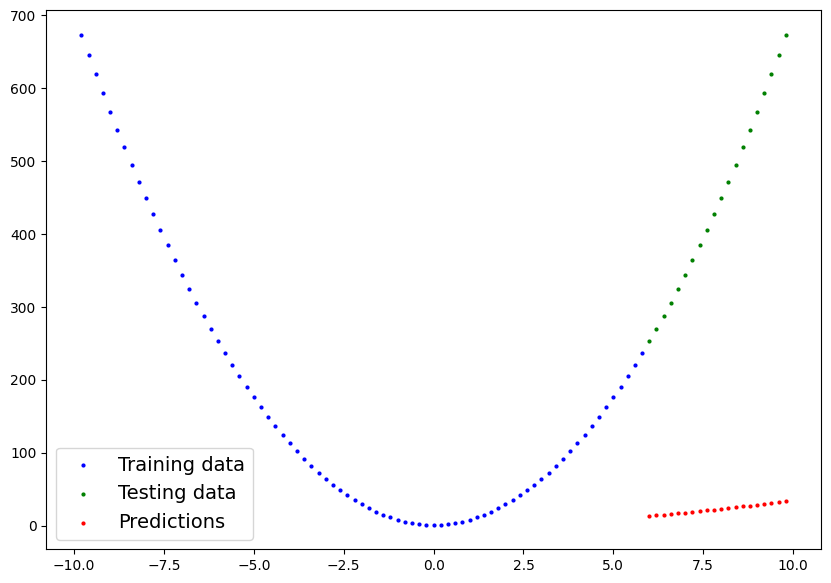

In [248]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [249]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error.

And,
SGD optimizer updates parameters to reduce error

In [250]:

torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 166.2732391357422 | MAE Test Loss: 408.8077697753906 
Epoch: 10 | MAE Train Loss: 104.26924896240234 | MAE Test Loss: 252.2126007080078 
Epoch: 20 | MAE Train Loss: 42.265235900878906 | MAE Test Loss: 95.61738586425781 
Epoch: 30 | MAE Train Loss: 2.1109044551849365 | MAE Test Loss: 6.325655937194824 
Epoch: 40 | MAE Train Loss: 1.2364046573638916 | MAE Test Loss: 8.994148254394531 
Epoch: 50 | MAE Train Loss: 1.0613176822662354 | MAE Test Loss: 9.8119478225708 
Epoch: 60 | MAE Train Loss: 1.1207554340362549 | MAE Test Loss: 10.009692192077637 
Epoch: 70 | MAE Train Loss: 0.8819864988327026 | MAE Test Loss: 10.844189643859863 
Epoch: 80 | MAE Train Loss: 0.9476461410522461 | MAE Test Loss: 10.903528213500977 
Epoch: 90 | MAE Train Loss: 1.4739694595336914 | MAE Test Loss: 9.812562942504883 
Epoch: 100 | MAE Train Loss: 1.0053342580795288 | MAE Test Loss: 11.123374938964844 
Epoch: 110 | MAE Train Loss: 0.6294490098953247 | MAE Test Loss: 12.171618461608887 
E

Output:

- Loss decreases over time.

- Model gradually learns correct curve


### Loss Curve Visualization

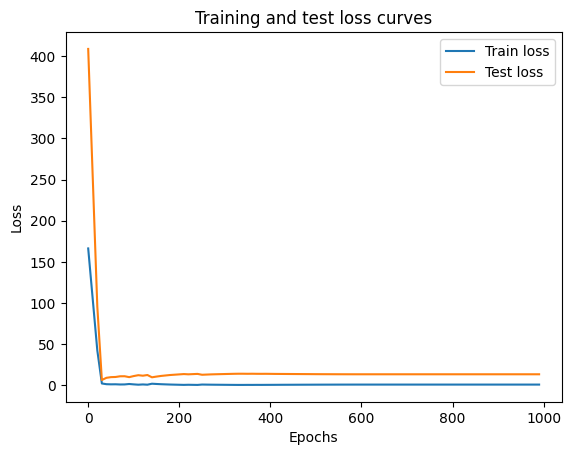

In [251]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

The curves shows training vs testing error which help to verify machine learning.

Output:

The decreasing curve shows that the model is learning.


### Final Prediction Visualization

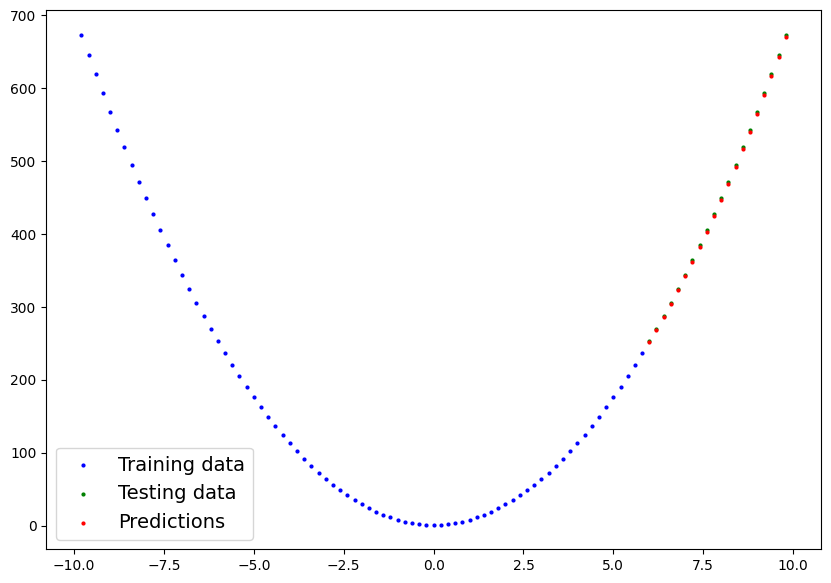

In [252]:

# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

--> The Red points (predictions) align closely with actual data Indicates successful learning of quadratic relationship

###  Discussion

In this lab activity, we used PyTorch to see how input and output variables are related. We took the dataset and turned it into something the computer(machine) could understand then we splitted it as training and testing variables. 

Then we created a model that learned two things:
 i) weight and ii) bias.
At first the model made guesses because it started with random numbers but after the model was eventually trained, it used MAE(Mean Absolute Error) to measure the mistakes the model made and a way to get better called SGD (Stochastic Gradient Descent).

As the model got trained, it made fewer mistakes and this was true for both training and testing parts. This illustrated that our model was really learning. 

Then we observed the set of predictions, from where we saw that they matched the true value closely which meant that our model had figured out the relation betn variables in the dataset.


### Conclusion

In this lab, we successfully trained regression models using PyTorch. As training progressed, we were able to minimize the loss value which proved that the model was learning correctly. Moreover, the final prediction closely matched with our actual data.